In [16]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import mlflow, sys
sys.path.append("/scratchsan/observatorio/juagudeloo/MUISCA")
from utils.mlflow_utils import default_tracking_uri


mlflow.set_tracking_uri(default_tracking_uri())   # sqlite:////.../MUISCA/mlruns.db

for e in mlflow.search_experiments():
    print(e.experiment_id, e.name)

plt.rcParams.update({
  'axes.titlesize': 'x-large',  # heading 1
  'axes.labelsize': 'large',   # heading 2
  'xtick.labelsize': 'large',         # fontsize of the ticks
  'ytick.labelsize': 'large',         # fontsize of the ticks
  'font.family': 'serif',        # Font family
  'text.usetex': False,          # Do not use LaTeX for text rendering
  'figure.figsize': (10, 8),     # Default figure size
  'savefig.dpi': 300,            # High resolution for saving figures
  'savefig.format': 'png',       # Default format for saving figures
  'legend.fontsize': 'large',  # Font size for legends
  'lines.linewidth': 2,          # Line width for plots
  'lines.markersize': 8,         # Marker size for plots,
  'axes.formatter.useoffset': False,  # Disable offset
  'axes.formatter.use_mathtext': True,  # Use scientific notation
  'axes.formatter.limits': (-3, 4),  # Use scientific notation for values over 10^2
  'axes.labelsize': 'large',     # Font size for axes labels
  'figure.titlesize': 'xx-large', # Font size for suptitles (heading 1)
  'axes.formatter.use_locale': False  # Do not use locale settings
})

notebooks_images_dir = Path("/scratchsan/observatorio/juagudeloo/MUISCA/notebooks/notebooks_images")


1 experiment_110_to_130-step_size_10-normal
0 Default


In [17]:

# Charge run experiments
runs = mlflow.search_runs(experiment_names=["experiment_110_to_130-step_size_10-normal"])

# RRMSE columns
rrmse_columns = runs.columns[np.logical_and(runs.columns.str.startswith("metrics.test"), runs.columns.str.endswith("rrmse"))]

# Corr columns
corr_columns = runs.columns[np.logical_and(runs.columns.str.startswith("metrics.test"), runs.columns.str.endswith("corr"))]

runs[runs["status"].eq('FINISHED') & runs["metrics.test_blos_rrmse"].notna()][["run_id", 
                                                                                "tags.mlflow.runName", 
                                                                                "status", 
                                                                                *rrmse_columns, 
                                                                                *corr_columns]]


,run_id,tags.mlflow.runName,status,metrics.test_vlos_rrmse,metrics.test_blos_rrmse,metrics.test_temp_rrmse,metrics.test_blos_corr,metrics.test_vlos_corr,metrics.test_temp_corr
0,5d8e6bcf7b5b4349b547bd70a157fd0e,doppler_only,FINISHED,2.404528,8.224766,0.507959,0.596771,0.715683,0.779361
2,7f7a6ea7c24344b69c7cadc65f11defe,doppler_only,FINISHED,4.314362,9.398586,0.516531,0.559423,-0.712604,0.778448
4,991e94faf25e41a8ba6cba8b4cacf8c7,black_body_only,FINISHED,4.234085,6.968543,0.520033,0.579617,-0.709252,0.789254
5,9e9a9f563ecc4d29be359fb8ed88037a,doppler_only,FINISHED,4.294844,10.539684,0.513910,0.654643,-0.720451,0.784458
9,d880849881444667b73afe2b8c8d0dc7,no_physics,FINISHED,4.317808,6.580765,0.515194,0.567632,-0.714622,0.783508
10,10f7e5fec4394b4782aa81b731a5c806,wfa_only,FINISHED,3.919872,2.175474,0.510130,0.662983,-0.761028,0.887513


In [18]:
import pandas as pd

client = mlflow.MlflowClient()

def metric_history(run_id, key):
    h = client.get_metric_history(run_id, key)
    return pd.DataFrame({"epoch": [m.step for m in h],
                         "value": [m.value for m in h]}).sort_values("epoch")

hist = metric_history("10f7e5fec4394b4782aa81b731a5c806", "train_wfa_loss")


In [ ]:
from utils.analysis import display_name

def metric_history_df(run_id, key):
    """Per-epoch history for one metric, or an empty DataFrame if the run never logged it
    (e.g. train_wfa_loss for an arm with lambda_wfa=0 -- that term is never computed)."""
    h = client.get_metric_history(run_id, key)
    if not h:
        return pd.DataFrame(columns=["epoch", "value"])
    return pd.DataFrame({"epoch": [m.step for m in h],
                          "value": [m.value for m in h]}).sort_values("epoch")

def _log_safe(values):
    """Non-positive values -> NaN, so matplotlib doesn't choke on a log-scale axis."""
    arr = np.asarray(values, dtype=float)
    return np.where(arr > 0, arr, np.nan)

def plot_loss_curves_from_mlflow(run_id, exp_name, save_dir=None):
    fig, axes = plt.subplots(2, 2, figsize=(10, 18))
    fig.suptitle(f'Loss Components - {display_name(exp_name)}', fontsize=14, fontweight='bold')


    gate_hist = client.get_metric_history(run_id, "wfa_gate_trigger_epoch")
    gate_epoch = gate_hist[-1].value if gate_hist else -1

    # Total loss
    ax1 = axes[0, 0]
    d = metric_history_df(run_id, "train_total_loss")
    ax1.plot(d.epoch, _log_safe(d.value), 'b-o', label='Total Loss', linewidth=2, markersize=3)
    if gate_epoch and gate_epoch > 0:
        ax1.axvline(x=gate_epoch, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label='Physics on')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Total Training Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_yscale('log')

    # MSE loss
    ax2 = axes[0, 1]
    d = metric_history_df(run_id, "train_mse_loss")
    ax2.plot(d.epoch, _log_safe(d.value), 'g-s', label='MSE Loss', linewidth=2, markersize=3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.set_title('MSE Loss Component')
    ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_yscale('log')

    # Physics loss breakdown
    ax3 = axes[1, 0]
    params = client.get_run(run_id).data.params
    lambda_map = {
        "train_wfa_loss": float(params.get("physics_config.lambda_wfa", 0)),
        "train_doppler_loss": float(params.get("physics_config.lambda_doppler", 0)),
        "train_temperature_loss": float(params.get("physics_config.lambda_temp", 0)),
    }
    has_active_physics = any(v > 0 for v in lambda_map.values())

    if has_active_physics:
        d = metric_history_df(run_id, "train_physics_loss")
        ax3.plot(d.epoch, _log_safe(d.value), "r-^", label="Total Physics", linewidth=2)

    for key, style, label in [
        ("train_wfa_loss", "m--", "WFA"),
        ("train_doppler_loss", "c--", "Doppler"),
        ("train_temperature_loss", "y--", "Temperature"),
    ]:
        if lambda_map[key] > 0:
            d = metric_history_df(run_id, key)
            ax3.plot(d.epoch, _log_safe(d.value), style, label=label, linewidth=1.5)

    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss'); ax3.set_title('Physics Loss Components')
    ax3.legend(); ax3.grid(True, alpha=0.3); ax3.set_yscale('log')

    # Validation loss
    ax4 = axes[1, 1]|
    d = metric_history_df(run_id, "val_loss")
    ax4.plot(d.epoch, _log_safe(d.value), color='orange', marker='o', label='Test Loss', linewidth=2, markersize=3)
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss'); ax4.set_title('Test Loss')
    ax4.legend(); ax4.grid(True, alpha=0.3); ax4.set_yscale('log')

    plt.tight_layout()
    if save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(f"{save_dir}/loss_curves_{exp_name}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


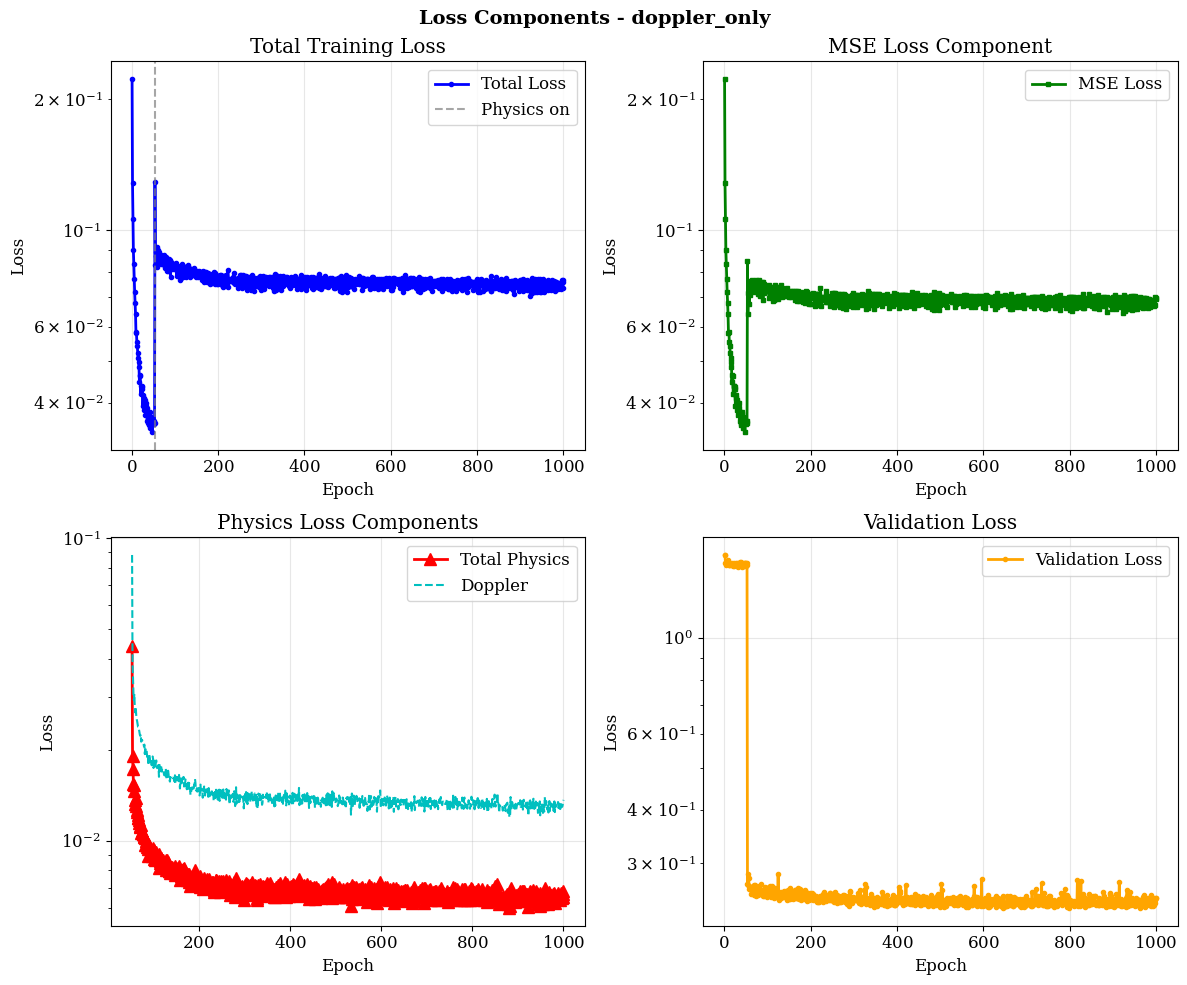

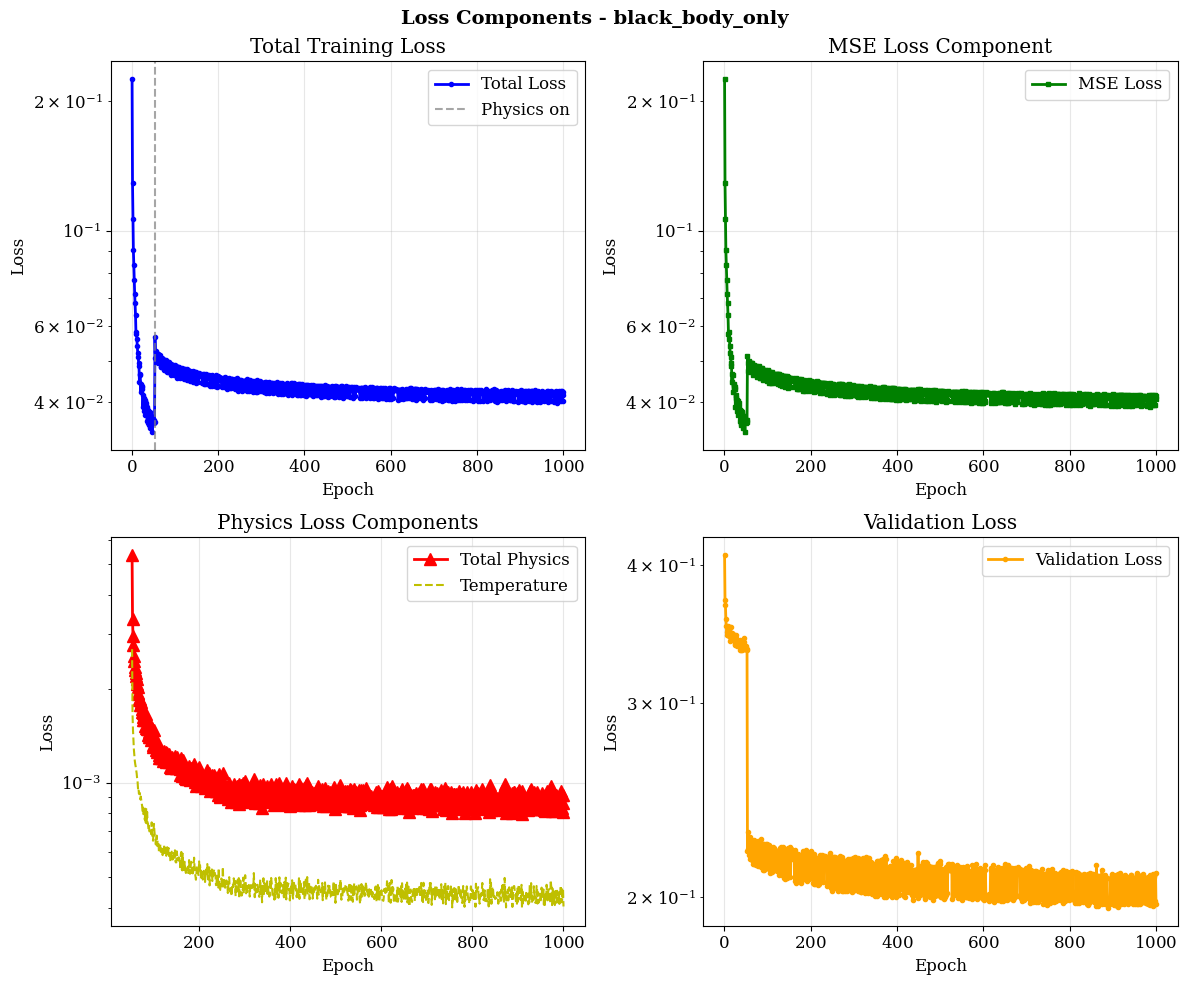

/tmp/ipykernel_15096/2436783417.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(); ax3.grid(True, alpha=0.3); ax3.set_yscale('log')


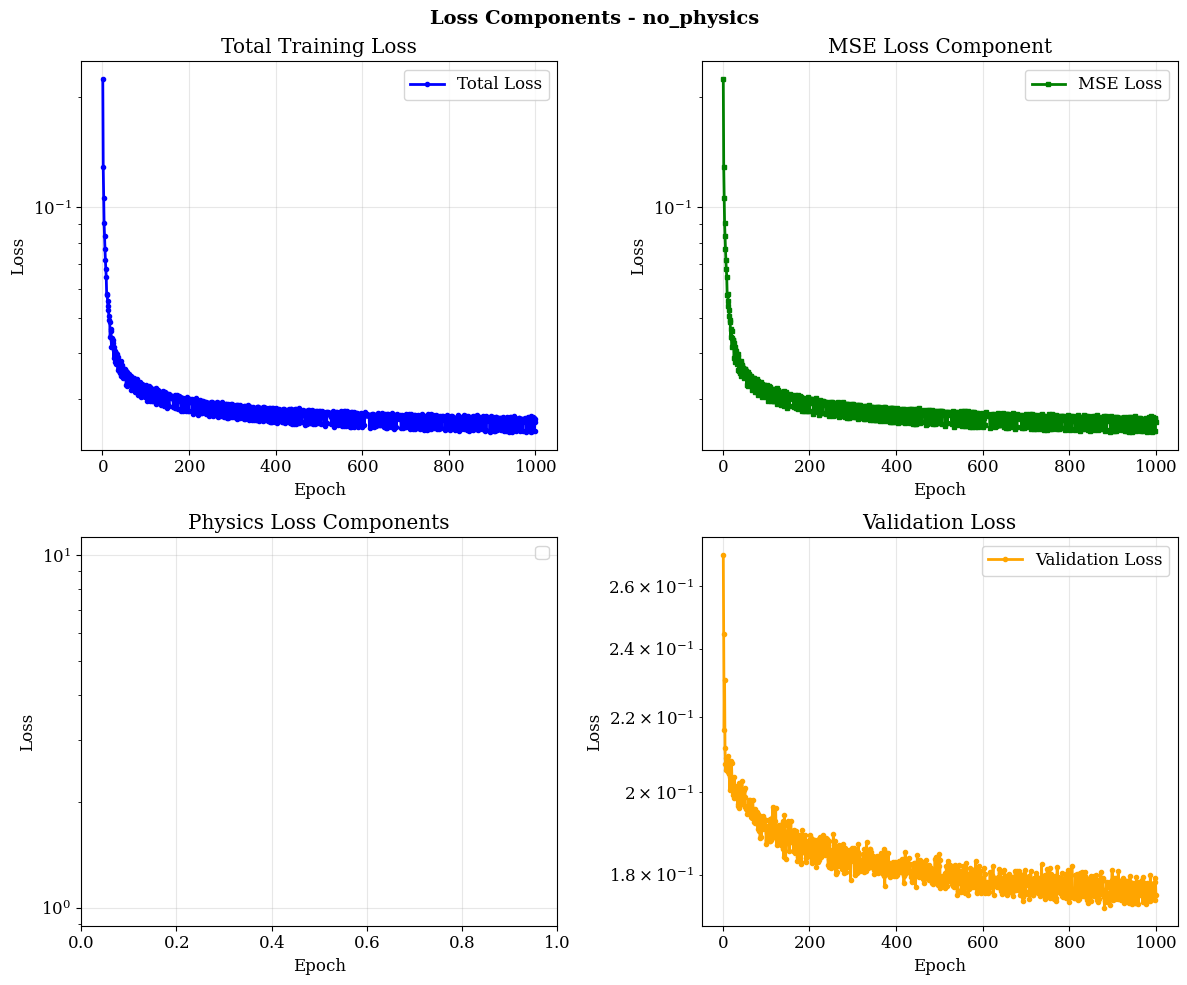

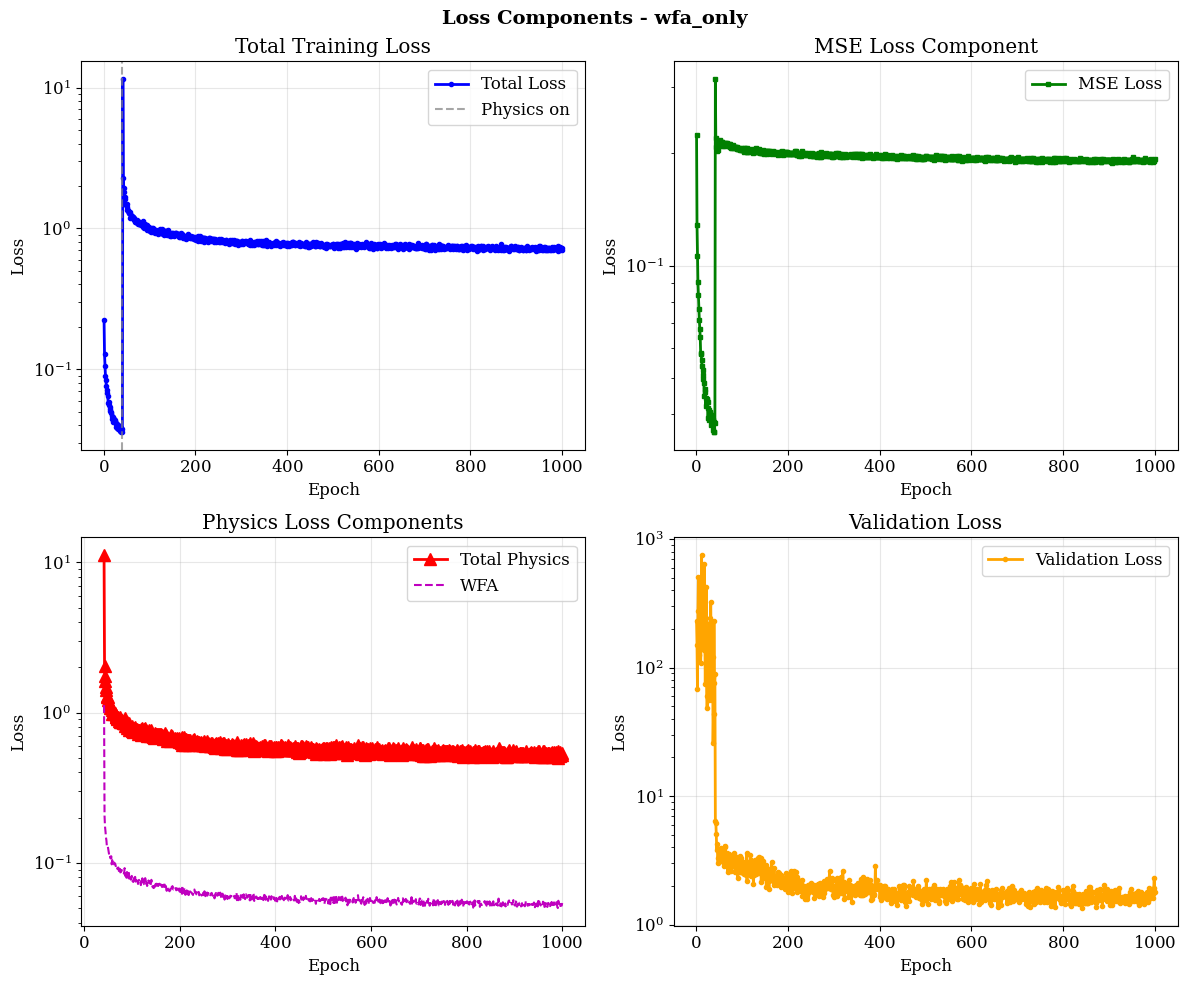

In [20]:
finished = runs[runs["status"].eq("FINISHED") & runs["metrics.test_blos_rrmse"].notna()]
run_id_by_arm = dict(zip(finished["tags.mlflow.runName"], finished["run_id"]))

for arm, run_id in run_id_by_arm.items():
    plot_loss_curves_from_mlflow(run_id, arm, save_dir = notebooks_images_dir / "loss_curves")